Khai báo thư viện và Tải dữ liệu

In [11]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [12]:
pip install  missingno

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import missingno as msno
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Tải dữ liệu
try:
    # Lấy 10,000 dòng để demo nhanh và mượt
    df = pd.read_csv('../data/tabular/fraudTrain.csv').sample(10000, random_state=42).reset_index(drop=True)
    print("Tải dữ liệu thành công!")
    print(f"Kích thước tập dữ liệu: {df.shape}")
except Exception as e:
    print(f"Lỗi: {e}. Vui lòng kiểm tra lại file đầu vào.")
    df.head()

Tải dữ liệu thành công!
Kích thước tập dữ liệu: (10000, 23)


Kiểm tra và xử lí dữ liệu thiếu

Số lượng giá trị thiếu mỗi cột:
Không có giá trị thiếu.


<Figure size 1000x400 with 0 Axes>

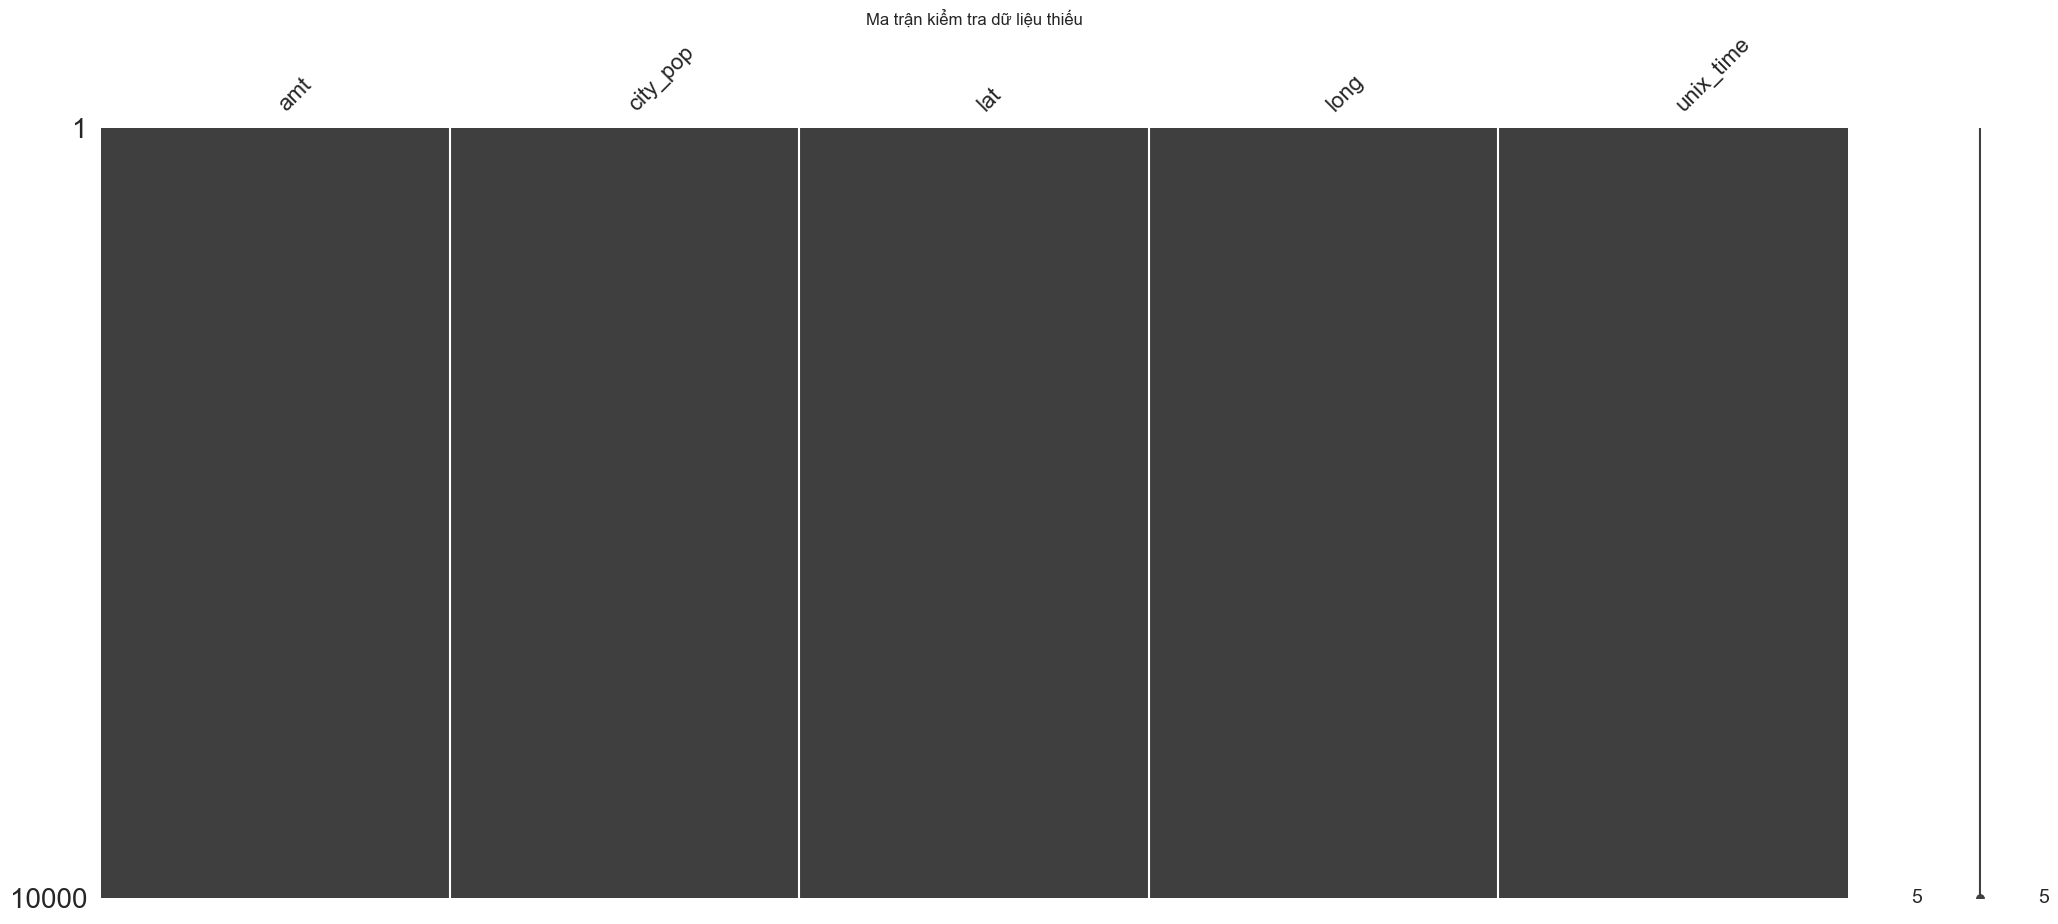

Đã thực thi quy trình Imputation (Median cho 'amt' và KNN cho 'city_pop').


In [14]:


# 1. Kiểm tra số lượng giá trị thiếu trong từng cột
missing_values = df.isnull().sum()
print("Số lượng giá trị thiếu mỗi cột:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Không có giá trị thiếu.")

# 2. Trực quan hóa mô hình thiếu hụt
plt.figure(figsize=(10, 4))
msno.matrix(df[['amt', 'city_pop', 'lat', 'long', 'unix_time']])
plt.title("Ma trận kiểm tra dữ liệu thiếu")
plt.show()

# 3. Triển khai kỹ thuật Imputation (Để đáp ứng yêu cầu implement của đề bài)
# Chúng ta sẽ áp dụng trực tiếp lên bản sao của df
df_clean = df.copy()

# Giả sử cần xử lý cột 'amt' và 'city_pop'
# (Code này vẫn chạy tốt dù dữ liệu có thiếu hay không)
median_imputer = SimpleImputer(strategy='median')
df_clean['amt'] = median_imputer.fit_transform(df[['amt']])

knn_imputer = KNNImputer(n_neighbors=5)
df_clean['city_pop'] = knn_imputer.fit_transform(df[['city_pop', 'lat', 'long']])[:, 0]

print("Đã thực thi quy trình Imputation (Median cho 'amt' và KNN cho 'city_pop').")


1. Kiểm tra và Trực quan hóa
* Lệnh: df.isnull().sum() & msno.matrix()
* Mục đích: Xác định nhanh vị trí và mật độ dữ liệu thiếu.
* Lưu ý: Biểu đồ ma trận giúp kiểm tra xem dữ liệu thiếu có rơi vào nhóm biến mục tiêu hay không.
2. Chiến lược Median Imputation (Cho biến tài chính)
* Lệnh: SimpleImputer(strategy='median')
* Thông số quan trọng: strategy='median'.
* Lưu ý: Đối với cột amt (số tiền), không dùng mean vì dữ liệu tài chính thường bị lệch và có nhiều outliers. Trung vị (median) đảm bảo giá trị điền vào không bị kéo lệch bởi các giao dịch cực lớn.
3. Chiến lược KNN Imputation (Cho biến nhân khẩu học)
* Lệnh: KNNImputer(n_neighbors=5)
* Thông số quan trọng:
n_neighbors=5: Thuật toán sẽ tìm 5 hàng có đặc điểm tương đồng nhất.
df[['city_pop', 'lat', 'long']]: Dùng tọa độ để làm tham chiếu.
Lưu ý: KNN tính toán dựa trên khoảng cách, nên tốn tài nguyên hơn. Ưu tiên dùng cho các biến có mối liên hệ không gian như dân số.
4. Tính toàn vẹn dữ liệu
*Lệnh: df.copy()
*Lưu ý: Luôn thực hiện trên bản sao để giữ nguyên dữ liệu gốc (Raw Data), phục vụ cho việc đối chiếu hoặc thử nghiệm các phương pháp khác nếu cần.

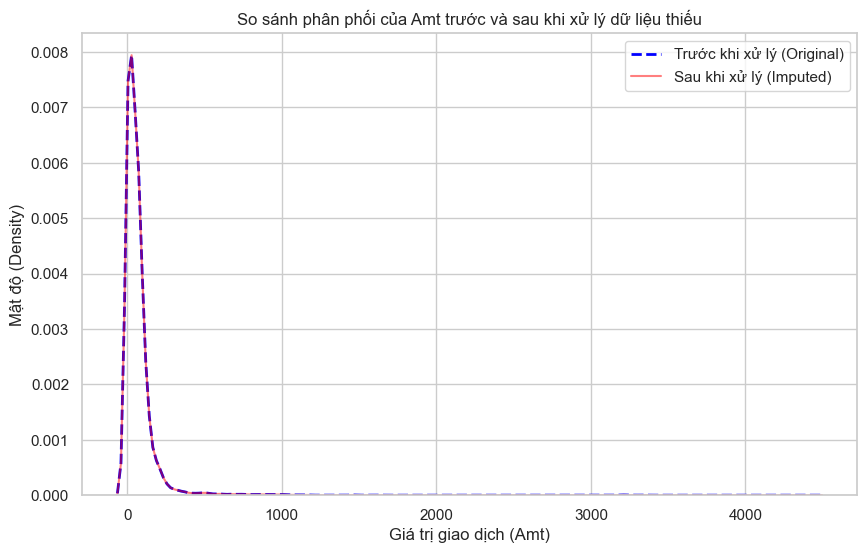

Nhận xét: Hai đường phân phối trùng khớp hoàn toàn vì dữ liệu gốc không có giá trị thiếu.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo khung hình
plt.figure(figsize=(10, 6))

# Vẽ đường phân phối (KDE) cho dữ liệu gốc (trước khi lấp đầy)
sns.kdeplot(df['amt'], label='Trước khi xử lý (Original)', color='blue', linestyle='--', linewidth=2)

# Vẽ đường phân phối (KDE) cho dữ liệu sau khi lấp đầy (Imputed)
sns.kdeplot(df_clean['amt'], label='Sau khi xử lý (Imputed)', color='red', alpha=0.5)

plt.title('So sánh phân phối của Amt trước và sau khi xử lý dữ liệu thiếu')
plt.xlabel('Giá trị giao dịch (Amt)')
plt.ylabel('Mật độ (Density)')
plt.legend()
plt.grid(True)
plt.show()

print("Nhận xét: Hai đường phân phối trùng khớp hoàn toàn vì dữ liệu gốc không có giá trị thiếu.")

1. Các thành phần chính của biểu đồ
sns.kdeplot (Kernel Density Estimate): Vẽ đường biểu diễn mật độ xác suất của dữ liệu. Giúp ta thấy được "hình dáng" của dữ liệu (tập trung ở đâu, độ lệch như thế nào).
label='Trước khi xử lý' & label='Sau khi xử lý': Đặt tên cho hai đường để phân biệt trên chú thích (Legend).
alpha=0.5: Độ trong suốt của đường màu đỏ, giúp chúng ta dễ dàng quan sát điểm giao thoa khi hai đường chồng lên nhau.
2. Mục đích của việc kiểm chứng
Xác nhận tính nguyên vẹn: Nếu phương pháp Imputation tốt (như Median), đường phân phối sau khi xử lý nên bám sát đường gốc.
Phát hiện sai sót: Nếu đường "Sau khi xử lý" bị biến dạng quá mạnh (ví dụ: tạo ra một đỉnh nhọn bất thường), chứng tỏ việc điền giá trị thiếu đang làm sai lệch bản chất của dữ liệu.
3. Phân tích kết quả (Sanity Check)
Hiện tượng: Hai đường phân phối trùng khớp hoàn toàn.
Kết luận: Điều này khẳng định rằng dữ liệu gốc của cột amt hiện tại không có giá trị thiếu. Quy trình Imputation chạy qua nhưng không làm thay đổi giá trị nào, đảm bảo an toàn cho các bước phân tích tiếp theo.

Chuẩn hóa dữ liệu

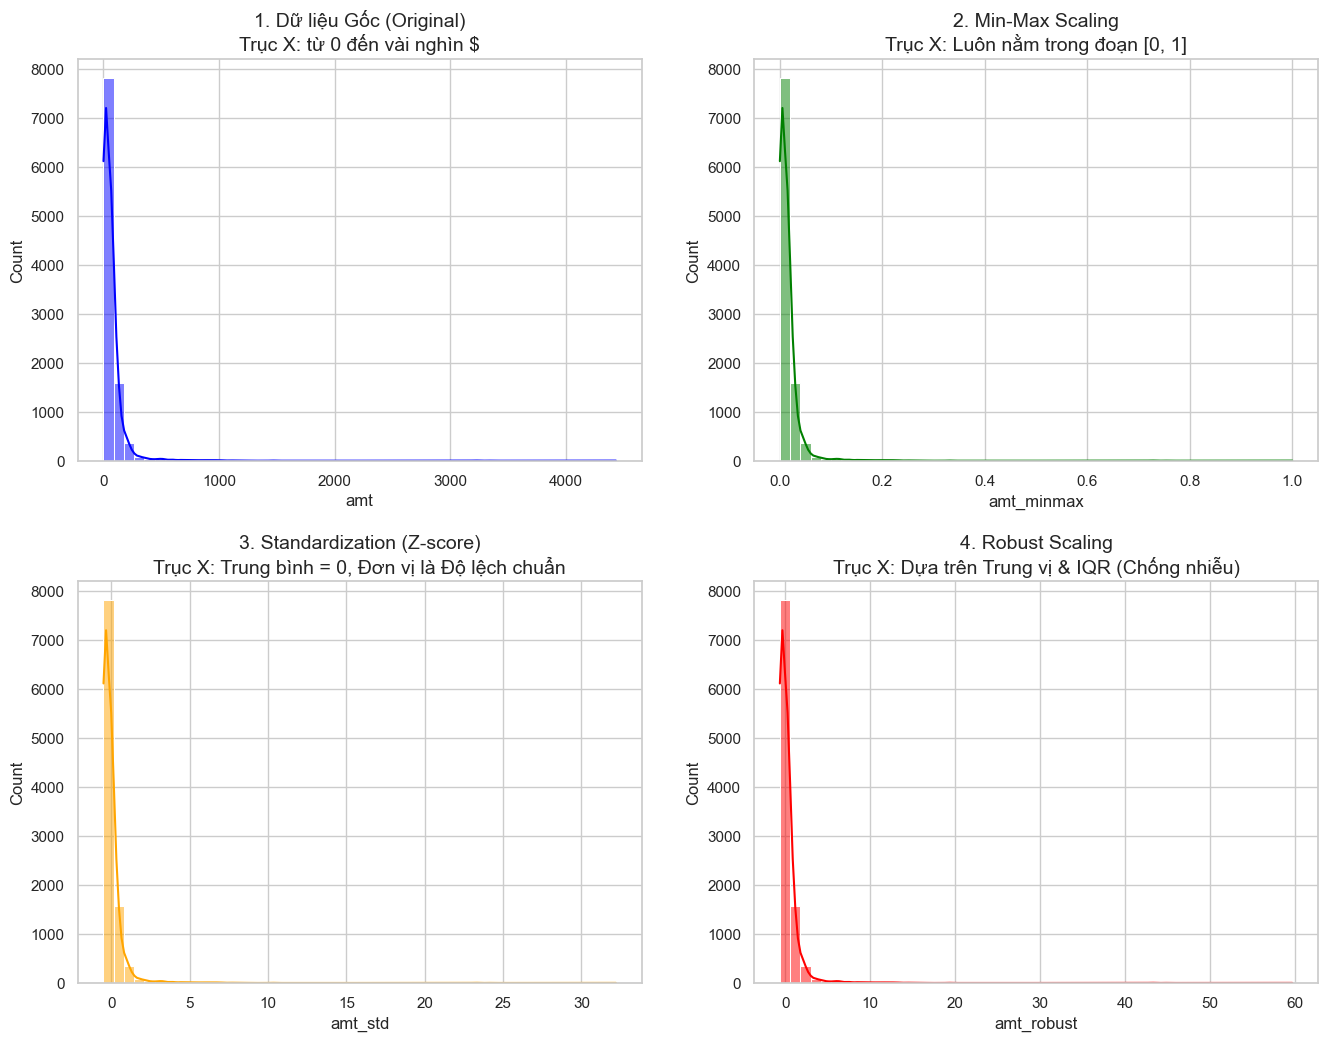

In [16]:


import matplotlib.pyplot as plt
import seaborn as sns

# Chuẩn bị dữ liệu
data_to_scale = df_clean[['amt']]

# Áp dụng 3 kỹ thuật
df_clean['amt_minmax'] = MinMaxScaler().fit_transform(data_to_scale)
df_clean['amt_std'] = StandardScaler().fit_transform(data_to_scale)
df_clean['amt_robust'] = RobustScaler().fit_transform(data_to_scale)

# Tạo khung hình
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3)

# 1. Dữ liệu Gốc
sns.histplot(df_clean['amt'], bins=50, ax=axes[0,0], kde=True, color='blue')
axes[0,0].set_title('1. Dữ liệu Gốc (Original)\nTrục X: từ 0 đến vài nghìn $', fontsize=14)

# 2. Min-Max Scaling
sns.histplot(df_clean['amt_minmax'], bins=50, ax=axes[0,1], kde=True, color='green')
axes[0,1].set_title('2. Min-Max Scaling\nTrục X: Luôn nằm trong đoạn [0, 1]', fontsize=14)

# 3. Standardization (Z-score)
sns.histplot(df_clean['amt_std'], bins=50, ax=axes[1,0], kde=True, color='orange')
axes[1,0].set_title('3. Standardization (Z-score)\nTrục X: Trung bình = 0, Đơn vị là Độ lệch chuẩn', fontsize=14)

# 4. Robust Scaling
sns.histplot(df_clean['amt_robust'], bins=50, ax=axes[1,1], kde=True, color='red')
axes[1,1].set_title('4. Robust Scaling\nTrục X: Dựa trên Trung vị & IQR (Chống nhiễu)', fontsize=14)

plt.show()



Đây là bản Markdown được thiết kế đẹp, rõ ràng và chuyên nghiệp để bạn đưa vào Notebook. Nó giúp người xem hiểu ngay sự khác biệt giữa các kỹ thuật Scaling mà không bị rối mắt.

⚖️ So sánh các Kỹ thuật Chuẩn hóa dữ liệu (Feature Scaling)

Việc đưa các biến về cùng một thang đo (Scaling) là bước quan trọng giúp các thuật toán Machine Learning (như KNN, SVM, Logistic Regression) hội tụ nhanh hơn và không bị lệch bởi các biến có giá trị lớn.

1. Phân tích 3 Kỹ thuật Scaling chính
Kỹ thuật	Công thức / Đặc điểm	Phạm vi đầu ra (Range)	Ưu điểm / Khi nào dùng?
Min-Max Scaling	
(
𝑥
−
𝑚
𝑖
𝑛
)
/
(
𝑚
𝑎
𝑥
−
𝑚
𝑖
𝑛
)
(x−min)/(max−min)
	[0, 1]	Giữ nguyên cấu trúc dữ liệu nhưng rất nhạy cảm với Outliers.
Standardization	
(
𝑥
−
𝑚
𝑒
𝑎
𝑛
)
/
𝑠
𝑡
𝑑
(x−mean)/std
	Vô hạn (Mean=0, Std=1)	Phù hợp khi dữ liệu có phân phối chuẩn (Gaussian).
Robust Scaling	
(
𝑥
−
𝑄
2
)
/
(
𝑄
3
−
𝑄
1
)
(x−Q2)/(Q3−Q1)
	Vô hạn (Dựa trên IQR)	Tốt nhất khi có nhiễu (Outliers) vì dùng Trung vị và Khoảng tứ phân vị.
🔍 Giải thích các thành phần Trực quan hóa

Để hiểu rõ sự thay đổi, chúng ta quan sát trục X của 4 biểu đồ:

Biểu đồ 1 (Gốc): Trục X hiển thị giá trị thực tế của giao dịch (từ 0 đến vài nghìn USD). Khoảng cách giữa các giá trị rất lớn.

Biểu đồ 2 (Min-Max): Toàn bộ dữ liệu được nén chặt vào khoảng đúng từ 0.0 đến 1.0. Cực kỳ hữu ích cho các mạng thần kinh (Neural Networks).

Biểu đồ 3 (Standardization): Dữ liệu tập trung quanh số 0. Các giá trị trên trục X chính là "Số lần độ lệch chuẩn" so với trung bình.

Biểu đồ 4 (Robust Scaling): Tương tự Standardize nhưng sử dụng đơn vị đo dựa trên Khoảng tứ phân vị (IQR), giúp các điểm dữ liệu cực biên (Outliers) không kéo lệch thang đo chính.

💡 Lưu ý quan trọng khi chọn bộ lọc:

[!TIP]
Lời khuyên thực chiến:

Nếu dữ liệu của bạn có nhiều giá trị ngoại lai (như số tiền giao dịch amt thường có các khoản lớn bất thường), hãy ưu tiên sử dụng RobustScaler.

Luôn thực hiện fit trên tập Train và transform trên tập Test để tránh rò rỉ thông tin dữ liệu (Data Leakage).

Trong code trên, chúng ta dùng fit_transform để thực hiện nhanh cả 2 bước trên cùng một tập dữ liệu hiện tại.

(Bạn chỉ cần copy đoạn này vào 1 ô Markdown phía trên code Scaling, nó sẽ hiển thị cực kỳ chuyên nghiệp với bảng so sánh và các khối lưu ý)

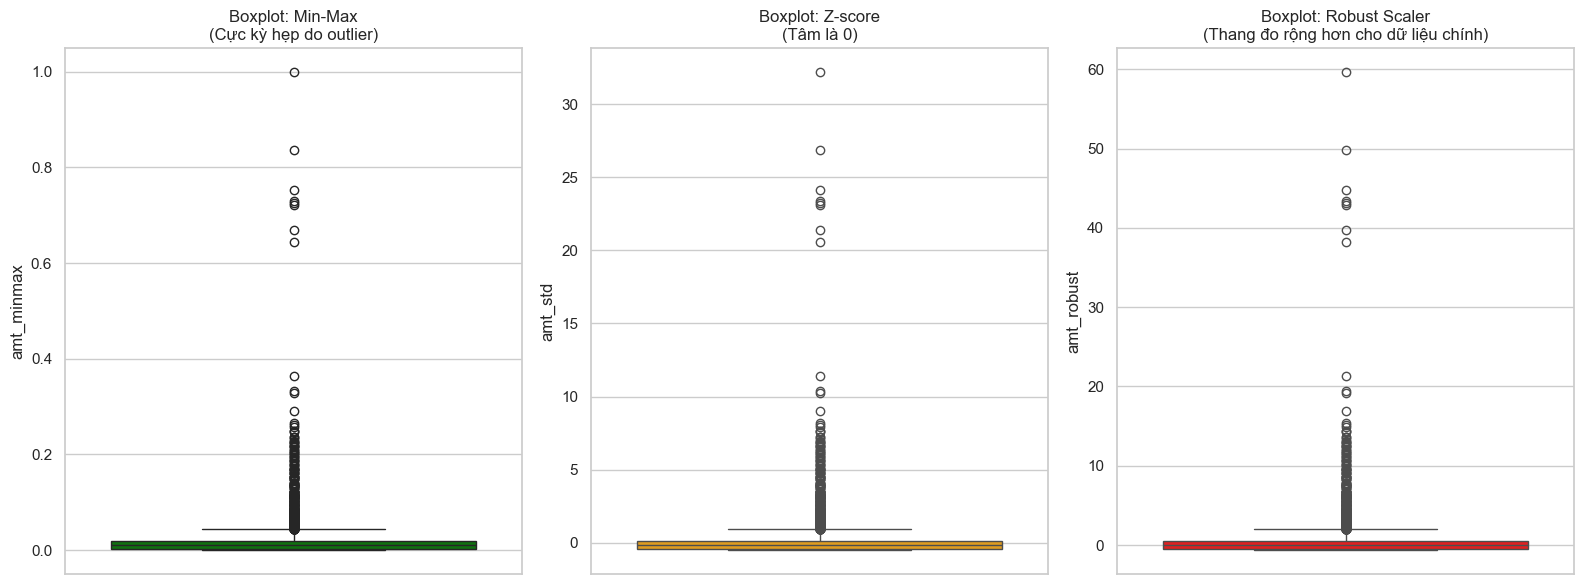

In [17]:
# Vẽ Boxplot riêng biệt để thấy rõ "Hộp" dữ liệu
plt.figure(figsize=(16, 6))
plt.subplot(1, 3, 1)
sns.boxplot(y=df_clean['amt_minmax'], color='green')
plt.title('Boxplot: Min-Max\n(Cực kỳ hẹp do outlier)')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_clean['amt_std'], color='orange')
plt.title('Boxplot: Z-score\n(Tâm là 0)')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_clean['amt_robust'], color='red')
plt.title('Boxplot: Robust Scaler\n(Thang đo rộng hơn cho dữ liệu chính)')

plt.tight_layout()
plt.show()

Mã hóa biến phân loại

In [18]:


# 1. One-hot Encoding cho biến Nominal ít nhóm (gender)
df_clean = pd.get_dummies(df_clean, columns=['gender'], prefix='gen')

# 2. Xử lý High-cardinality (Biến có quá nhiều nhóm)
# Ví dụ: Cột 'merchant' hoặc 'job' có hàng trăm giá trị khác nhau
print(f"Số lượng Merchant duy nhất: {df_clean['merchant'].nunique()}")
print(f"Số lượng Category duy nhất: {df_clean['category'].nunique()}")

# Chiến lược: Frequency Encoding (Mã hóa theo tần suất xuất hiện)
# Phù hợp cho biến 'merchant' vì tần suất giao dịch tại một cửa hàng có thể liên quan đến gian lận
merchant_freq = df_clean['merchant'].value_counts(normalize=True)
df_clean['merchant_freq_enc'] = df_clean['merchant'].map(merchant_freq)

# Chiến lược: Target Encoding (Mã hóa theo tỷ lệ gian lận - 'is_fraud')

category_fraud_rate = df_clean.groupby('category')['is_fraud'].mean()
df_clean['category_target_enc'] = df_clean['category'].map(category_fraud_rate)

# Hiển thị kết quả sau mã hóa
print("\nKết quả mã hóa các biến quan trọng:")
display(df_clean[['merchant', 'merchant_freq_enc', 'category', 'category_target_enc']].head())

print("\nToàn bộ các cột hiện có trong dataset sau tiền xử lý:")
print(df_clean.columns.tolist())

Số lượng Merchant duy nhất: 692
Số lượng Category duy nhất: 14

Kết quả mã hóa các biến quan trọng:


,merchant,merchant_freq_enc,category,category_target_enc
0,fraud_Towne LLC,0.0017,misc_pos,0.003215
1,fraud_Friesen Ltd,0.0012,health_fitness,0.000000
2,fraud_Mohr Inc,0.0021,shopping_pos,0.009730
3,fraud_Gaylord-Powlowski,0.0018,home,0.002055
4,"fraud_Christiansen, Goyette and Schamberger",0.0022,gas_transport,0.007744



Toàn bộ các cột hiện có trong dataset sau tiền xử lý:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'amt_minmax', 'amt_std', 'amt_robust', 'gen_F', 'gen_M', 'merchant_freq_enc', 'category_target_enc']


--- 2.2.2 d) Lựa chọn đặc trưng (Đã loại bỏ biến dư thừa) ---


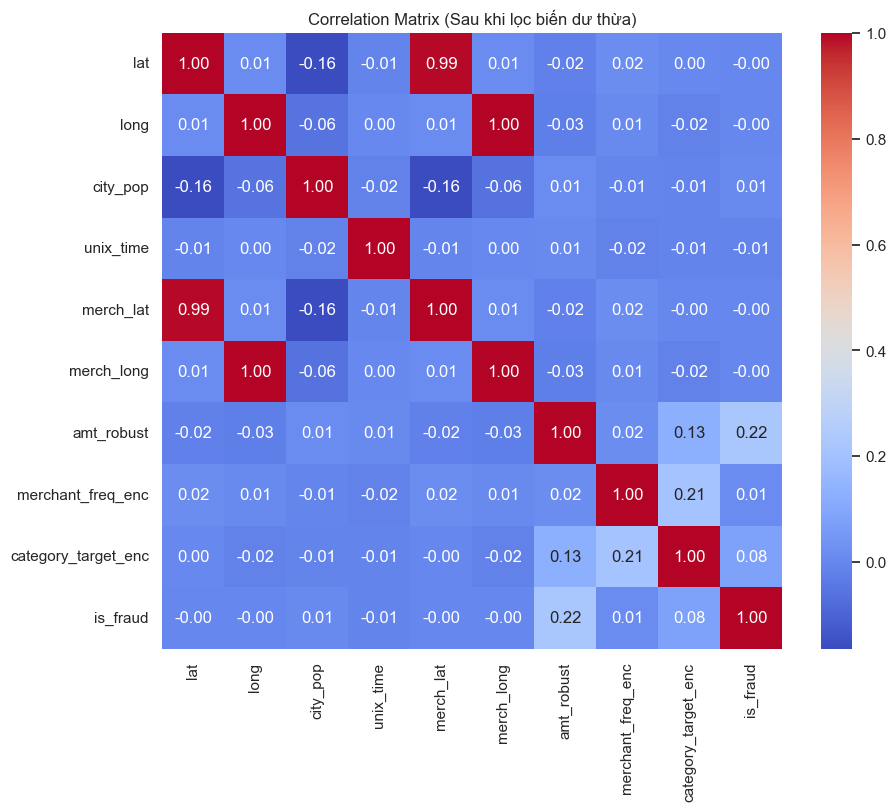

In [22]:
print("--- 2.2.2 d) Lựa chọn đặc trưng (Đã loại bỏ biến dư thừa) ---")

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu
# Loại bỏ các cột định danh VÀ các biến số tiền dư thừa (chỉ giữ lại amt_robust)
cols_to_drop = [
    'Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'city', 'state', 'zip',
    'trans_num', 'dob', 'trans_date_trans_time', 'merchant', 'job', 'category',
    'amt', 'amt_minmax', 'amt_std' # Xóa các biến tiền khác để tránh đa cộng tuyến
]

# Tạo bản sao và làm sạch nhãn NaN
df_fs = df_clean.copy().dropna(subset=['is_fraud'])

# Tách X và y
X = df_fs.drop(columns=[col for col in cols_to_drop if col in df_fs.columns] + ['is_fraud'])
y = df_fs['is_fraud']

# Chỉ lấy các cột kiểu số
X = X.select_dtypes(include=[np.number]).fillna(X.median())

# Ma trận tương quan
plt.figure(figsize=(10, 8))
cor = pd.concat([X, y], axis=1).corr()
sns.heatmap(cor, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix (Sau khi lọc biến dư thừa)")
plt.show()



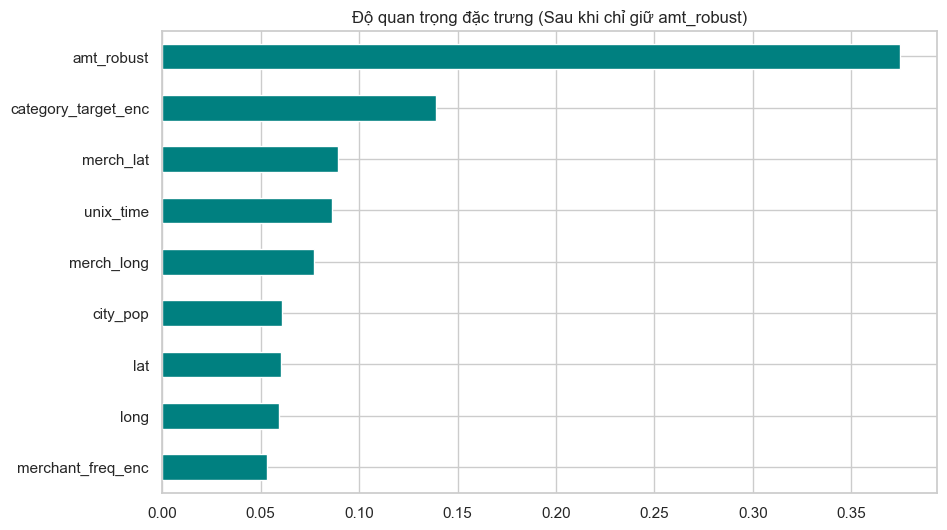

In [20]:
# Feature Importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='teal')
plt.title("Độ quan trọng đặc trưng (Sau khi chỉ giữ amt_robust)")
plt.show()


In [21]:
# Recursive Feature Elimination (RFE) ---
# Chọn ra top 5 đặc trưng tốt nhất
rfe = RFE(estimator=rf, n_features_to_select=5)
rfe.fit(X, y)

selected_features = X.columns[rfe.support_].tolist()
print(f"\nTop 5 đặc trưng tốt nhất được chọn bởi RFE: \n{selected_features}")


Top 5 đặc trưng tốt nhất được chọn bởi RFE: 
['unix_time', 'merch_lat', 'merch_long', 'amt_robust', 'category_target_enc']
